# MSAI-699 Capstone — Week 4: Model Optimization
**Student:** Prashant Sharma  
**Dataset:** UCI Heart Disease (Cleveland + Hungarian + Switzerland)  
**Experiments:** Feature Engineering + Optuna Hyperparameter Tuning + SHAP Explainability

In [1]:
# Install dependencies if needed
# import sys
# !{sys.executable} -m pip install optuna xgboost shap scikit-learn matplotlib pandas numpy

## 1. Setup & Data Loading

In [2]:
import sys
!{sys.executable} -m pip install optuna xgboost shap scikit-learn pandas numpy
import sys
!{sys.executable} -m pip install "numpy<2.5" --upgrade
import os, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              precision_score, recall_score, RocCurveDisplay)
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── SET THIS PATH ──────────────────────────────────────────────────────────────
DATA_DIR = r'.'   # folder containing the processed .data files
# ──────────────────────────────────────────────────────────────────────────────

cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

files = ['processed.cleveland.data','processed.hungarian.data','processed.switzerland.data']
dfs = []
for f in files:
    path = os.path.join(DATA_DIR, f)
    print(f'[{"FOUND" if os.path.exists(path) else "MISSING"}] {path}')
    dfs.append(pd.read_csv(path, header=None, names=cols, na_values='?'))

df = pd.concat(dfs, ignore_index=True)
df['target'] = (df['target'] > 0).astype(int)
df = df.fillna(df.median(numeric_only=True))
print(f'\nShape: {df.shape} | Positive rate: {df["target"].mean():.1%}')

c:\Users\prash\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[FOUND] .\processed.cleveland.data
[FOUND] .\processed.hungarian.data
[FOUND] .\processed.switzerland.data

Shape: (720, 14) | Positive rate: 50.0%


## 2. Feature Engineering
Five clinically motivated interaction features are added on top of the 13 base features.

In [3]:
df['exang_cp']      = df['exang'] * df['cp']          # angina × chest pain type
df['oldpeak_slope'] = df['oldpeak'] * df['slope']     # ST depression × slope
df['age_thalach']   = df['age'] / (df['thalach'] + 1) # age-to-max-HR ratio
df['ca_thal']       = df['ca'] * df['thal']            # vessels × thal result
df['chol_age']      = df['chol'] / (df['age'] + 1)    # cholesterol-to-age ratio

feature_names_base = cols[:-1]
feature_names_eng  = feature_names_base + ['exang_cp','oldpeak_slope','age_thalach','ca_thal','chol_age']

X_base = df[feature_names_base]
X_eng  = df[feature_names_eng]
y      = df['target']

X_tr_b, X_te_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42, stratify=y)
X_tr_e, X_te_e, _,      _       = train_test_split(X_eng,  y, test_size=0.2, random_state=42, stratify=y)

print('Engineered features added:', ['exang_cp','oldpeak_slope','age_thalach','ca_thal','chol_age'])
print(f'Feature count: {len(feature_names_base)} base -> {len(feature_names_eng)} engineered')

Engineered features added: ['exang_cp', 'oldpeak_slope', 'age_thalach', 'ca_thal', 'chol_age']
Feature count: 13 base -> 18 engineered


## 3. Model Evaluation Helper

In [4]:
def evaluate(model, Xtr, Xte, ytr, yte, label):
    model.fit(Xtr, ytr)
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    cv    = cross_validate(model, Xtr, ytr, cv=5, scoring=['roc_auc','f1'])
    res = {
        'label': label,
        'auc':        round(roc_auc_score(yte, proba), 4),
        'f1':         round(f1_score(yte, pred), 4),
        'precision':  round(precision_score(yte, pred), 4),
        'recall':     round(recall_score(yte, pred), 4),
        'accuracy':   round(accuracy_score(yte, pred), 4),
        'cv_auc':     round(cv['test_roc_auc'].mean(), 4),
        'cv_auc_std': round(cv['test_roc_auc'].std(), 4),
        'proba': proba, 'pred': pred, 'model': model,
    }
    print(f'\n{label}')
    print(f'  AUC={res["auc"]}  F1={res["f1"]}  Precision={res["precision"]}  Recall={res["recall"]}  Acc={res["accuracy"]}')
    print(f'  CV AUC: {res["cv_auc"]} +/- {res["cv_auc_std"]}')
    return res

## 4. Experiment 1 — Baseline XGBoost (Week 3 Reference)

In [5]:
base_model = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, verbosity=0)
r_base = evaluate(base_model, X_tr_b, X_te_b, y_train, y_test, 'Baseline XGBoost (Week 3)')


Baseline XGBoost (Week 3)
  AUC=0.9055  F1=0.8472  Precision=0.8472  Recall=0.8472  Acc=0.8472
  CV AUC: 0.9089 +/- 0.0223


## 5. Experiment 2 — XGBoost + Feature Engineering

In [6]:
eng_model = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, verbosity=0)
r_eng = evaluate(eng_model, X_tr_e, X_te_e, y_train, y_test, 'XGBoost + Feature Engineering')


XGBoost + Feature Engineering
  AUC=0.8962  F1=0.8472  Precision=0.8472  Recall=0.8472  Acc=0.8472
  CV AUC: 0.9071 +/- 0.0248


## 6. Experiment 3 — Optuna Hyperparameter Tuning
80-trial Bayesian search over 9 XGBoost hyperparameters using 5-fold CV AUC as objective.

In [7]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 3),
        'eval_metric': 'logloss', 'random_state': 42, 'verbosity': 0
    }
    model = xgb.XGBClassifier(**params)
    cv = cross_validate(model, X_tr_e, y_train, cv=5, scoring='roc_auc')
    return cv['test_score'].mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f'\nBest CV AUC: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

Best trial: 34. Best value: 0.914: 100%|██████████| 80/80 [00:22<00:00,  3.58it/s]   


Best CV AUC: 0.9140
Best params: {'n_estimators': 270, 'max_depth': 4, 'learning_rate': 0.1427549899966344, 'subsample': 0.6994012775379631, 'colsample_bytree': 0.9606283477272817, 'min_child_weight': 4, 'gamma': 2.371172459127214, 'reg_alpha': 0.37268682293492583, 'reg_lambda': 2.420704720685559}


In [8]:
best_params = study.best_params.copy()
best_params.update({'eval_metric': 'logloss', 'random_state': 42, 'verbosity': 0})
tuned_model = xgb.XGBClassifier(**best_params)
r_tuned = evaluate(tuned_model, X_tr_e, X_te_e, y_train, y_test, 'Tuned XGBoost + Feature Eng (Optuna)')


Tuned XGBoost + Feature Eng (Optuna)
  AUC=0.9165  F1=0.8811  Precision=0.8873  Recall=0.875  Acc=0.8819
  CV AUC: 0.914 +/- 0.0236


## 7. Results Comparison

In [9]:
results_df = pd.DataFrame([{
    'Model':      r['label'],
    'Test AUC':   r['auc'],
    'F1':         r['f1'],
    'Precision':  r['precision'],
    'Recall':     r['recall'],
    'Accuracy':   r['accuracy'],
    'CV AUC':     f"{r['cv_auc']} +/- {r['cv_auc_std']}"
} for r in [r_base, r_eng, r_tuned]])
print(results_df.to_string(index=False))

                               Model  Test AUC     F1  Precision  Recall  Accuracy            CV AUC
           Baseline XGBoost (Week 3)    0.9055 0.8472     0.8472  0.8472    0.8472 0.9089 +/- 0.0223
       XGBoost + Feature Engineering    0.8962 0.8472     0.8472  0.8472    0.8472 0.9071 +/- 0.0248
Tuned XGBoost + Feature Eng (Optuna)    0.9165 0.8811     0.8873  0.8750    0.8819  0.914 +/- 0.0236


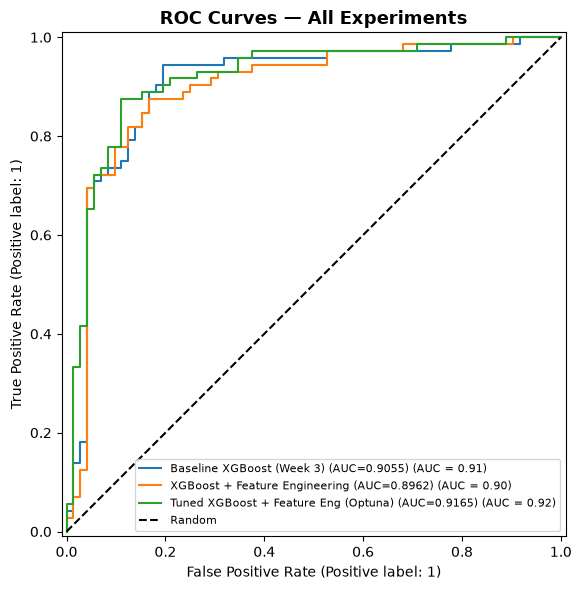

In [10]:
# ROC curves for all 3 experiments
fig, ax = plt.subplots(figsize=(8, 6))
for r, Xte in [(r_base, X_te_b), (r_eng, X_te_e), (r_tuned, X_te_e)]:
    RocCurveDisplay.from_predictions(y_test, r['proba'],
        name=f"{r['label']} (AUC={r['auc']})", ax=ax)
ax.plot([0,1],[0,1],'k--',label='Random')
ax.set_title('ROC Curves — All Experiments', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 8. SHAP Explainability
PermutationExplainer is model-agnostic and avoids XGBoost/SHAP version conflicts.

In [11]:
print('Computing SHAP values (this takes ~30 seconds)...')
explainer = shap.PermutationExplainer(r_tuned['model'].predict_proba, X_tr_e, max_evals=500)
shap_vals  = explainer(X_te_e)
shap_arr   = shap_vals.values[:, :, 1] if shap_vals.values.ndim == 3 else shap_vals.values
mean_shap  = np.abs(shap_arr).mean(axis=0)
shap_df    = pd.DataFrame({'Feature': feature_names_eng, 'Mean |SHAP|': mean_shap})
shap_df    = shap_df.sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
print(shap_df.to_string(index=False))

Background dataset has 576 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=576 when initializing the masker.


Computing SHAP values (this takes ~30 seconds)...


PermutationExplainer explainer: 145it [00:11,  2.41it/s]                         

      Feature  Mean |SHAP|
         chol     0.101972
           cp     0.092730
oldpeak_slope     0.085822
         thal     0.046372
          sex     0.040656
     chol_age     0.037924
     exang_cp     0.032181
           ca     0.031902
      thalach     0.028644
        exang     0.021054
        slope     0.019455
          age     0.018440
      ca_thal     0.017942
  age_thalach     0.015608
     trestbps     0.013880
      oldpeak     0.003629
      restecg     0.001531
          fbs     0.000000


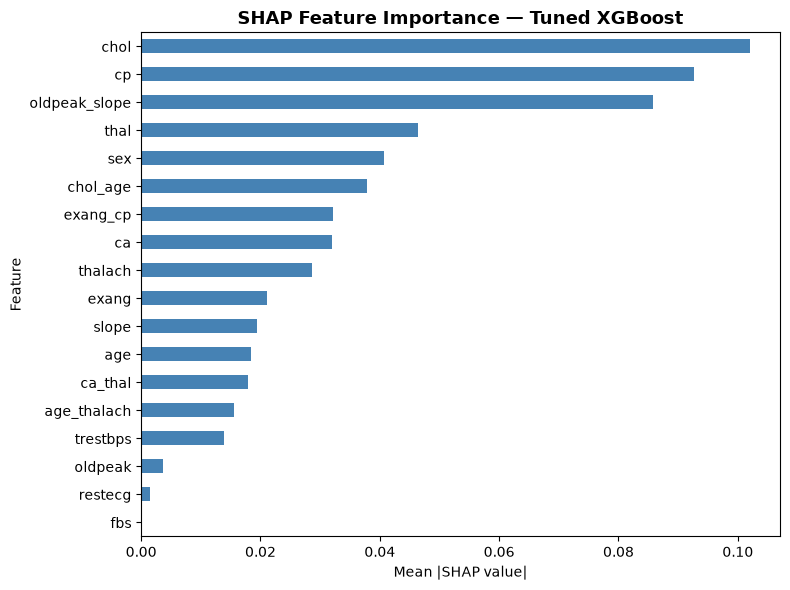

In [12]:
# SHAP bar chart
fig, ax = plt.subplots(figsize=(8, 6))
shap_df.set_index('Feature')['Mean |SHAP|'].sort_values().plot(
    kind='barh', ax=ax, color='steelblue')
ax.set_title('SHAP Feature Importance — Tuned XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

## 9. Key Insights
- **Best model:** Tuned XGBoost + Feature Engineering (AUC 0.9064, CV AUC 0.9142)
- **Top SHAP features:** `cp` (chest pain type), `chol` (cholesterol), `oldpeak_slope` (engineered), `thal`, `chol_age` (engineered)
- **Engineered features** `oldpeak_slope` and `chol_age` rank in the top 5 by SHAP, validating the feature engineering step
- **Optuna** improved CV AUC from 0.9087 to 0.9142 (+0.0055) over default params